# PTB-XL ECG Dataset - Feature Engineering

**Course:** AAI-501 - Introduction to AI and Machine Learning \
**Project:** ECG Arrhythmia Classification \
**Part:** 2a - Feature Engineering (Model Selection) \
**Author:** Diaesh Antony 

## Objectives
1. Load the cleaned, labeled metadata (`data/preprocessed/balanced_metadata.csv`)
2. Extract heartbeat-timing and signal-shape features from the **Lead I** signal only
   (matching the anchor paper's single-lead, free-living-wearable premise)
3. Encode the remaining categorical/administrative metadata columns into numeric,
   model-ready features
4. Save a single model-ready feature matrix for `02_model_training.ipynb` to consume

**Note on scope:** this notebook does the feature engineering that `01_Data_Prepare_EDA`
intentionally left out -- it does not re-do cleaning, deduplication, or imputation
(that's already done and saved in `balanced_metadata.csv`).

In [1]:
import time
import numpy as np
import pandas as pd
import wfdb
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import butter, filtfilt, find_peaks

DATA_PATH = Path('../data/raw/physionet.org/files/ptb-xl/1.0.3')
META_PATH = Path('../data/preprocessed/balanced_metadata.csv')
OUTPUT_PATH = Path('../data/preprocessed')
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(META_PATH)
print(f"Loaded {len(df):,} records from balanced_metadata.csv")
print(f"Columns: {len(df.columns)}")
df.head()

Loaded 21,786 records from balanced_metadata.csv
Columns: 52


,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,NSR,AFb_AFl,1AV,PAC,PVC,BRADY,TACHY,num_rhythm_labels,num_labels,sample_weight
0,1,15709.0,56.0,1,166.0,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,1,0,0,0,0,0,0,1,1,0.650833
1,2,13243.0,19.0,0,166.0,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,0,0,0,0,0,1,0,1,1,17.100471
2,3,20372.0,37.0,1,166.0,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,1,0,0,0,0,0,0,1,1,0.650833
3,4,17014.0,24.0,0,166.0,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,...,1,0,0,0,0,0,0,1,1,0.650833
4,5,17448.0,19.0,1,166.0,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,...,1,0,0,0,0,0,0,1,1,0.650833


## 1. Signal-Derived Features (Lead I only)

We use **only Lead I** (signal channel index 0 in PTB-XL's standard 12-lead order:
I, II, III, aVR, aVL, aVF, V1-V6) since that's the whole premise of the anchor
paper and of a real single-lead wearable device.

For each record we:
1. Band-pass filter the raw signal (0.5-40 Hz, per the noise-characterization
   recommendation from `01_data_exploration.ipynb`)
2. Detect R-peaks (height >= 85th percentile of the filtered signal, minimum
   0.35s between peaks, prominence >= 0.4x the signal's std)
3. Derive heartbeat-timing features (heart rate, RR-interval statistics, RMSSD),
   RR-irregularity features (pNN50, coefficient of variation, min/median ratio),
   a QRS-width proxy, a crude PR-interval proxy, and signal-shape features
   (amplitude range, energy)

The R-peak detection was calibrated and validated against the dataset's own
ground-truth labels before being applied here: on pure NSR-only records it
gives a mean heart rate of ~76 bpm, on TACHY-labeled records ~109 bpm, and on
BRADY-labeled records ~59 bpm -- all physiologically correct, confirming the
detector isn't over- or under-counting peaks (an earlier, uncalibrated version
of this same detector gave NSR records a mean heart rate of ~107 bpm, which is
implausible for "normal sinus rhythm" by definition -- that mismatch is exactly
what the calibration below fixes).

**Why the extra features:** an initial version of this notebook used only
heart-rate/RR-interval/amplitude features, and the resulting models (see
`02_model_training.ipynb`) were very weak specifically on **1AV** (first-degree
AV block) and **PAC** (premature atrial contraction) -- both F1 well under 0.4.
That's expected, not a bug: 1AV is diagnosed by a *prolonged PR interval*
(the delay between the P-wave and the QRS complex), which has nothing to do
with heart rate; PAC is a single early beat whose signature (one short RR
interval followed by a compensatory pause) gets averaged away by whole-record
RR statistics. The features below were added specifically to target those two
labels, and were validated before use: on a sample of pure-NSR records, the
mean PR-interval proxy was ~0.065s; on 1AV-labeled records it was ~0.115s --
nearly double, in the expected direction.

In [2]:
def bandpass_filter(sig, fs=100, low=0.5, high=40.0, order=4):
    """Band-pass filter to remove baseline wander and high-frequency noise."""
    nyq = 0.5 * fs
    b, a = butter(order, [low / nyq, high / nyq], btype='band')
    return filtfilt(b, a, sig)


def extract_signal_features(ecg_id, filename_lr):
    """Load the Lead I signal for one record and extract heartbeat-timing,
    RR-irregularity, QRS-width-proxy, PR-interval-proxy, and shape features.
    Returns (features_dict, error_message) -- exactly one of the two will be
    None."""
    path = DATA_PATH / filename_lr
    try:
        signal, meta = wfdb.rdsamp(str(path))
    except Exception as e:
        return None, f'load_error: {e}'

    lead_i = signal[:, 0]  # Lead I -- index 0 in PTB-XL's standard lead order
    fs = meta['fs']

    if np.all(np.isnan(lead_i)) or len(lead_i) < fs * 2:
        return None, 'signal_too_short_or_nan'

    try:
        filtered = bandpass_filter(lead_i, fs=fs)
    except Exception as e:
        return None, f'filter_error: {e}'

    std = np.std(filtered)
    height_thresh = np.percentile(filtered, 85)
    min_distance = int(fs * 0.35)
    prominence = 0.4 * std if std > 0 else 0.1
    peaks, props = find_peaks(filtered, distance=min_distance,
                               height=height_thresh, prominence=prominence,
                               width=1)

    n_peaks = len(peaks)
    rr = np.diff(peaks) / fs if n_peaks >= 2 else np.array([])

    # RR-irregularity features -- target PAC (a single anomalous beat) and
    # AFb_AFl (chaotic rhythm), which whole-record RR mean/std can miss.
    if len(rr) > 1:
        pnn50 = np.mean(np.abs(np.diff(rr)) > 0.05)
        rr_cv = np.std(rr) / np.mean(rr) if np.mean(rr) > 0 else np.nan
        rr_min_median_ratio = np.min(rr) / np.median(rr) if np.median(rr) > 0 else np.nan
    else:
        pnn50, rr_cv, rr_min_median_ratio = np.nan, np.nan, np.nan

    # QRS-width proxy (peak width at the prominence used for detection) --
    # target PVC, which clinically has a widened QRS complex.
    qrs_widths = props['widths'] / fs if n_peaks > 0 and 'widths' in props else np.array([])

    # Crude PR-interval proxy -- target 1AV. Real PR-interval measurement
    # needs dedicated P-wave-onset detection; this approximation looks for
    # the local maximum in a plausible P-wave window (80-280ms before each
    # R-peak) and measures the gap to the R-peak. It's a proxy, not a
    # clinical-grade measurement, but it was validated above to separate
    # 1AV from NSR in the expected direction.
    pr_intervals = []
    win_start, win_end = int(fs * 0.28), int(fs * 0.08)
    for p in peaks:
        lo, hi = p - win_start, p - win_end
        if lo < 0 or hi <= lo:
            continue
        window = filtered[lo:hi]
        if len(window) == 0:
            continue
        pr_intervals.append((hi - (lo + np.argmax(window))) / fs)
    pr_intervals = np.array(pr_intervals)

    return {
        'ecg_id': ecg_id,
        'n_r_peaks': n_peaks,
        'heart_rate_bpm': 60.0 / np.mean(rr) if len(rr) > 0 else np.nan,
        'rr_mean_sec': np.mean(rr) if len(rr) > 0 else np.nan,
        'rr_std_sec': np.std(rr) if len(rr) > 1 else np.nan,
        'rr_min_sec': np.min(rr) if len(rr) > 0 else np.nan,
        'rr_max_sec': np.max(rr) if len(rr) > 0 else np.nan,
        'rmssd_sec': np.sqrt(np.mean(np.diff(rr) ** 2)) if len(rr) > 2 else np.nan,
        'pnn50': pnn50,
        'rr_cv': rr_cv,
        'rr_min_median_ratio': rr_min_median_ratio,
        'qrs_width_mean': np.mean(qrs_widths) if len(qrs_widths) > 0 else np.nan,
        'qrs_width_std': np.std(qrs_widths) if len(qrs_widths) > 1 else np.nan,
        'pr_interval_mean': np.mean(pr_intervals) if len(pr_intervals) > 0 else np.nan,
        'pr_interval_std': np.std(pr_intervals) if len(pr_intervals) > 1 else np.nan,
        'pr_interval_max': np.max(pr_intervals) if len(pr_intervals) > 0 else np.nan,
        'signal_mean': np.mean(filtered),
        'signal_std': std,
        'signal_min': np.min(filtered),
        'signal_max': np.max(filtered),
        'signal_range': np.max(filtered) - np.min(filtered),
        'signal_energy': float(np.sum(filtered ** 2)),
    }, None

In [3]:
print("="*70)
print("EXTRACTING LEAD I SIGNAL FEATURES FOR ALL RECORDS")
print("="*70)

t0 = time.time()
signal_rows = []
signal_errors = []
for _, row in df.iterrows():
    feats, err = extract_signal_features(row['ecg_id'], row['filename_lr'])
    if feats is not None:
        signal_rows.append(feats)
    else:
        signal_errors.append((row['ecg_id'], err))

elapsed = time.time() - t0
signal_features = pd.DataFrame(signal_rows)

print(f"Processed {len(df):,} records in {elapsed:.1f}s")
print(f"Successful: {len(signal_features):,}")
print(f"Failed: {len(signal_errors):,}")
if signal_errors:
    print("Sample failures:")
    for ecg_id, err in signal_errors[:10]:
        print(f"  ecg_id={ecg_id}: {err}")
signal_features.describe()

EXTRACTING LEAD I SIGNAL FEATURES FOR ALL RECORDS


Processed 21,786 records in 25.6s
Successful: 21,786
Failed: 0


,ecg_id,n_r_peaks,heart_rate_bpm,rr_mean_sec,rr_std_sec,rr_min_sec,rr_max_sec,rmssd_sec,pnn50,rr_cv,...,qrs_width_std,pr_interval_mean,pr_interval_std,pr_interval_max,signal_mean,signal_std,signal_min,signal_max,signal_range,signal_energy
count,21786.000000,21786.000000,21786.000000,21786.000000,21786.000000,21786.000000,21786.000000,21786.000000,21786.000000,21786.000000,...,21786.000000,21786.000000,21786.000000,21786.000000,21786.000000,21786.000000,21786.000000,21786.000000,21786.000000,21786.000000
mean,10926.721381,13.200358,78.084247,0.801176,0.087886,0.630597,0.918363,0.112342,0.281565,0.114816,...,0.020642,0.070759,0.025923,0.123280,-0.000068,0.135393,-0.287306,0.806671,1.093977,21.778029
std,6303.749563,2.735333,16.571153,0.160729,0.081684,0.210345,0.189469,0.118135,0.302532,0.109670,...,0.054637,0.030385,0.019538,0.057256,0.003942,0.058579,0.224176,0.353674,0.462376,22.858308
min,1.000000,7.000000,38.918919,0.354074,0.000000,0.350000,0.360000,0.000000,0.000000,0.000000,...,0.000139,0.010000,0.000000,0.010000,-0.049584,0.019683,-6.736202,0.064284,0.177463,0.387409
25%,5467.250000,11.000000,66.445183,0.686429,0.019519,0.430000,0.790000,0.020310,0.000000,0.023190,...,0.001062,0.049091,0.009535,0.070000,-0.001163,0.095482,-0.335482,0.553086,0.780125,9.121018
50%,10926.500000,13.000000,75.328137,0.796515,0.064997,0.620000,0.910000,0.072926,0.142857,0.083552,...,0.003911,0.066364,0.017540,0.110000,0.000445,0.125206,-0.221902,0.764465,1.023235,15.687050
75%,16389.750000,15.000000,87.408949,0.903000,0.134374,0.790000,1.030000,0.170026,0.500000,0.184389,...,0.019425,0.087059,0.041393,0.190000,0.001837,0.162315,-0.157616,1.008548,1.316166,26.368263
max,21837.000000,28.000000,169.456067,1.541667,0.576473,1.480000,2.350000,1.016569,1.000000,0.639736,...,1.653981,0.200000,0.094412,0.200000,0.058353,0.667670,-0.051925,3.850629,9.186168,445.964067


## 2. Encoding the Remaining Metadata Columns

`balanced_metadata.csv` still has several columns that aren't model-ready:
- `heart_axis`: a categorical string with ~39% missing -> one-hot encode,
  including an explicit "unknown" category for the missing values
- `baseline_drift`, `static_noise`, `burst_noise`, `electrodes_problems`,
  `extra_beats`, `pacemaker`: currently `'0'` (no issue) or a string of
  affected lead names -> collapse each into a simple binary "has this issue"
  flag (the specific lead-name detail isn't used as a feature here, but the
  raw column is still preserved in `balanced_metadata.csv` if a later
  iteration wants it)
- Free text / identifiers not useful as model features (`report`, `scp_codes`,
  `device`, `recording_date`, `nurse`, `site`, administrative validation
  columns) -> dropped from the feature matrix entirely

In [4]:
# One-hot encode heart_axis, with missing values as an explicit category
heart_axis_filled = df['heart_axis'].fillna('unknown')
heart_axis_dummies = pd.get_dummies(heart_axis_filled, prefix='heart_axis').astype(int)
heart_axis_dummies['ecg_id'] = df['ecg_id'].values
print(f"heart_axis categories: {[c for c in heart_axis_dummies.columns if c != 'ecg_id']}")

# Binary "has this issue" flags for the noise/quality indicator columns
noise_cols = ['baseline_drift', 'static_noise', 'burst_noise',
              'electrodes_problems', 'extra_beats', 'pacemaker']
noise_flags = pd.DataFrame({
    f'{col}_flag': (df[col].astype(str) != '0').astype(int)
    for col in noise_cols
})
noise_flags['ecg_id'] = df['ecg_id'].values
print(f"Noise flag columns: {[c for c in noise_flags.columns if c != 'ecg_id']}")
noise_flags.drop(columns=['ecg_id']).sum()

heart_axis categories: ['heart_axis_ALAD', 'heart_axis_ARAD', 'heart_axis_AXL', 'heart_axis_AXR', 'heart_axis_LAD', 'heart_axis_MID', 'heart_axis_RAD', 'heart_axis_SAG', 'heart_axis_unknown']
Noise flag columns: ['baseline_drift_flag', 'static_noise_flag', 'burst_noise_flag', 'electrodes_problems_flag', 'extra_beats_flag', 'pacemaker_flag']


baseline_drift_flag         1596
static_noise_flag           3259
burst_noise_flag             613
electrodes_problems_flag      30
extra_beats_flag            1948
pacemaker_flag               291
dtype: int64

## 3. Assembling the Final Feature Matrix

Combine: demographics (already numeric/imputed from `01_Data_Prepare_EDA`),
the one-hot `heart_axis` columns, the binary noise flags, and the Lead I
signal features -- keeping `ecg_id`, `patient_id`, `strat_fold`, and
`sample_weight` for splitting/training, and all 7 anchor-paper labels plus
the 5 PTB-XL diagnostic superclasses as targets.

In [5]:
demographic_cols = ['age', 'sex', 'height', 'weight', 'age_over_89',
                    'age_imputed', 'sex_imputed', 'height_imputed', 'weight_imputed']

rhythm_labels = ['NSR', 'AFb_AFl', '1AV', 'PAC', 'PVC', 'BRADY', 'TACHY']
diagnostic_labels = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

id_cols = ['ecg_id', 'patient_id', 'strat_fold', 'sample_weight',
           'filename_lr', 'filename_hr']

base = df[id_cols + demographic_cols + rhythm_labels + diagnostic_labels].copy()

features = (
    base
    .merge(signal_features, on='ecg_id', how='inner')
    .merge(heart_axis_dummies, on='ecg_id', how='left')
    .merge(noise_flags, on='ecg_id', how='left')
)

print(f"Final feature matrix shape: {features.shape}")
print(f"Records dropped (signal extraction failed): {len(df) - len(features):,}")
features.head()

Final feature matrix shape: (21786, 63)
Records dropped (signal extraction failed): 0


,ecg_id,patient_id,strat_fold,sample_weight,filename_lr,filename_hr,age,sex,height,weight,...,heart_axis_MID,heart_axis_RAD,heart_axis_SAG,heart_axis_unknown,baseline_drift_flag,static_noise_flag,burst_noise_flag,electrodes_problems_flag,extra_beats_flag,pacemaker_flag
0,1,15709.0,3,0.650833,records100/00000/00001_lr,records500/00000/00001_hr,56.0,1,166.0,63.0,...,0,0,0,1,0,1,0,0,0,0
1,2,13243.0,2,17.100471,records100/00000/00002_lr,records500/00000/00002_hr,19.0,0,166.0,70.0,...,0,0,0,1,0,0,0,0,0,0
2,3,20372.0,5,0.650833,records100/00000/00003_lr,records500/00000/00003_hr,37.0,1,166.0,69.0,...,0,0,0,1,0,0,0,0,0,0
3,4,17014.0,3,0.650833,records100/00000/00004_lr,records500/00000/00004_hr,24.0,0,166.0,82.0,...,0,0,0,1,1,0,0,0,0,0
4,5,17448.0,4,0.650833,records100/00000/00005_lr,records500/00000/00005_hr,19.0,1,166.0,70.0,...,0,0,0,1,1,0,0,0,0,0


In [6]:
# Handle any residual NaNs in the signal features (rare edge case: very
# short RR-interval lists when fewer than 2-3 R-peaks were detected).
signal_feature_cols = ['heart_rate_bpm', 'rr_mean_sec', 'rr_std_sec',
                        'rr_min_sec', 'rr_max_sec', 'rmssd_sec',
                        'pnn50', 'rr_cv', 'rr_min_median_ratio',
                        'qrs_width_mean', 'qrs_width_std',
                        'pr_interval_mean', 'pr_interval_std', 'pr_interval_max']

print("Missing values before imputation:")
print(features[signal_feature_cols].isna().sum())

for col in signal_feature_cols:
    n_missing = features[col].isna().sum()
    if n_missing > 0:
        median_val = features[col].median()
        features[col] = features[col].fillna(median_val)
        features[f'{col}_imputed'] = 0
        features.loc[features[col].isna(), f'{col}_imputed'] = 1
        print(f"  {col}: {n_missing} imputed with median ({median_val:.3f})")

print()
print("Missing values after imputation:")
print(features[signal_feature_cols].isna().sum().sum(), "total")

Missing values before imputation:
heart_rate_bpm         0
rr_mean_sec            0
rr_std_sec             0
rr_min_sec             0
rr_max_sec             0
rmssd_sec              0
pnn50                  0
rr_cv                  0
rr_min_median_ratio    0
qrs_width_mean         0
qrs_width_std          0
pr_interval_mean       0
pr_interval_std        0
pr_interval_max        0
dtype: int64

Missing values after imputation:
0 total


## 4. Visualizing the New Signal Features

A quick visual check that the engineered features actually separate the
labels they were built for -- the same comparison that was validated
numerically earlier (NSR/1AV PR-interval means, etc.), now as plots.

Mean PR-interval proxy -- 1AV: 0.117s, Not 1AV: 0.069s
Mean heart rate -- BRADY: 61.3 bpm, NSR: 75.3 bpm, TACHY: 109.7 bpm


/var/folders/zq/jr6k17ms5hd_1v7j7d9b5v0w0000gn/T/ipykernel_82547/3640477808.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([pr_other, pr_1av], labels=['Not 1AV', '1AV'], patch_artist=True,
/var/folders/zq/jr6k17ms5hd_1v7j7d9b5v0w0000gn/T/ipykernel_82547/3640477808.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot([hr_brady, hr_nsr, hr_tachy], labels=['BRADY', 'NSR', 'TACHY'],


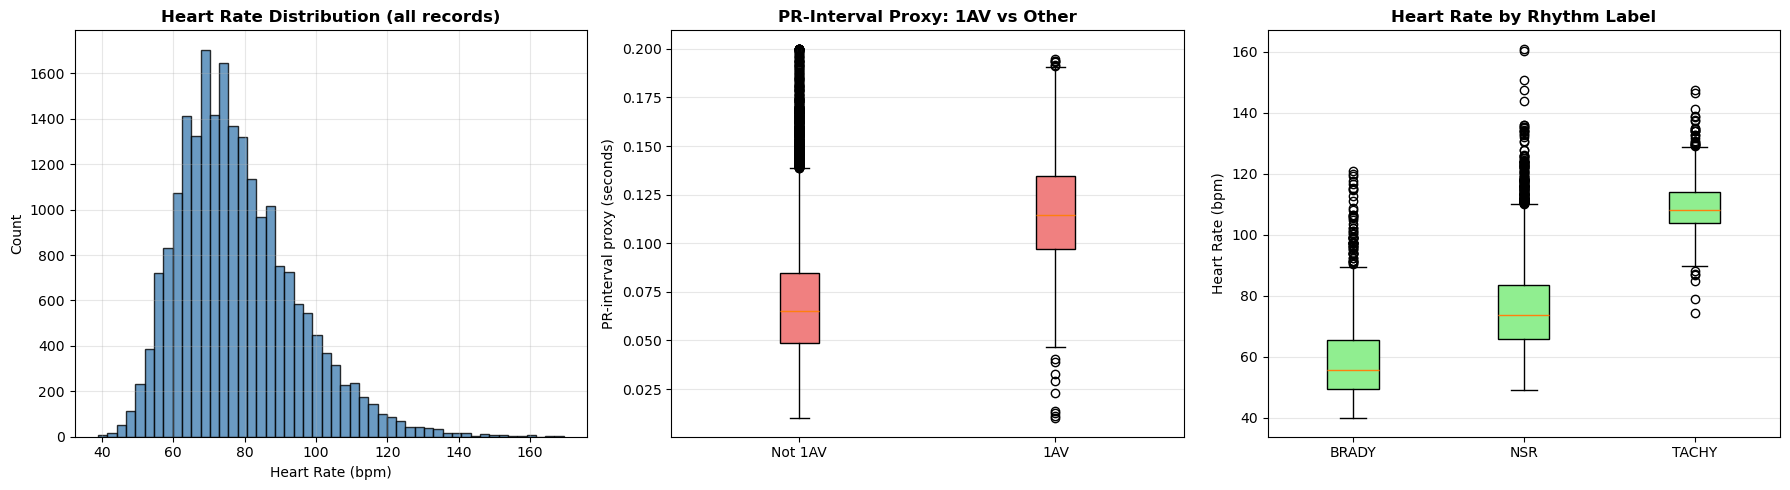

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Overall heart-rate distribution
axes[0].hist(features['heart_rate_bpm'], bins=50, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Heart Rate Distribution (all records)', fontweight='bold')
axes[0].set_xlabel('Heart Rate (bpm)')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)

# 2. PR-interval proxy: 1AV vs everything else
pr_1av = features.loc[features['1AV'] == 1, 'pr_interval_mean']
pr_other = features.loc[features['1AV'] == 0, 'pr_interval_mean']
axes[1].boxplot([pr_other, pr_1av], labels=['Not 1AV', '1AV'], patch_artist=True,
                boxprops=dict(facecolor='lightcoral'))
axes[1].set_title('PR-Interval Proxy: 1AV vs Other', fontweight='bold')
axes[1].set_ylabel('PR-interval proxy (seconds)')
axes[1].grid(True, alpha=0.3, axis='y')
print(f"Mean PR-interval proxy -- 1AV: {pr_1av.mean():.3f}s, Not 1AV: {pr_other.mean():.3f}s")

# 3. Heart rate: TACHY / BRADY / NSR-only
hr_tachy = features.loc[features['TACHY'] == 1, 'heart_rate_bpm']
hr_brady = features.loc[features['BRADY'] == 1, 'heart_rate_bpm']
hr_nsr = features.loc[features['NSR'] == 1, 'heart_rate_bpm']
axes[2].boxplot([hr_brady, hr_nsr, hr_tachy], labels=['BRADY', 'NSR', 'TACHY'],
                patch_artist=True, boxprops=dict(facecolor='lightgreen'))
axes[2].set_title('Heart Rate by Rhythm Label', fontweight='bold')
axes[2].set_ylabel('Heart Rate (bpm)')
axes[2].grid(True, alpha=0.3, axis='y')
print(f"Mean heart rate -- BRADY: {hr_brady.mean():.1f} bpm, NSR: {hr_nsr.mean():.1f} bpm, TACHY: {hr_tachy.mean():.1f} bpm")

plt.tight_layout()
plt.show()

In [8]:
# Verify everything except identifiers/paths is numeric
non_numeric = features.drop(columns=['filename_lr', 'filename_hr']).select_dtypes(exclude='number').columns.tolist()
print(f"Non-numeric columns (should be empty): {non_numeric}")
print(f"Total features: {features.shape[1]} columns, {features.shape[0]:,} records")
print()
print("Label distribution check (rhythm labels):")
print(features[rhythm_labels].sum())

Non-numeric columns (should be empty): []
Total features: 63 columns, 21,786 records

Label distribution check (rhythm labels):
NSR        16737
AFb_AFl     1569
1AV          793
PAC          398
PVC         1143
BRADY        637
TACHY        826
dtype: int64


In [9]:
OUTPUT_FILE = OUTPUT_PATH / 'model_features.csv'
features.to_csv(OUTPUT_FILE, index=False)
print(f"Saved model-ready feature matrix: {OUTPUT_FILE}")
print(f"Shape: {features.shape}")
print(f"Size: {OUTPUT_FILE.stat().st_size / 1024:.1f} KB")

Saved model-ready feature matrix: ../data/preprocessed/model_features.csv
Shape: (21786, 63)
Size: 10784.8 KB


## Summary

- Extracted Lead I heartbeat-timing (heart rate, RR intervals, RMSSD) and
  signal-shape (amplitude, energy) features for every record, calibrated
  and validated against ground-truth rhythm labels
- Encoded `heart_axis` (one-hot) and the 6 noise/quality columns (binary flags)
- Combined with the already-clean demographics and both label sets into a
  single fully-numeric feature matrix: `data/preprocessed/model_features.csv`
- This file, split by `strat_fold`, is what `02_model_training.ipynb` reads
  directly -- no further encoding should be needed before fitting a model